## 1st Financial Report (Raw)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [14]:
# importación y limpieza del set
flow = pd.read_csv('Techsavers_flow.csv', header = 1)
flow.columns = ['Fecha','Categoria','Nombre','Cantidad','Medio','Compras','Faltante']
flow['Fecha'] = pd.to_datetime(flow['Fecha'], format = '%d.%m.%y', errors='coerce')   

In [15]:
flow.head()

,Fecha,Categoria,Nombre,Cantidad,Medio,Compras,Faltante
0,2026-02-16,NaN,Simone Britt,230.0,Xavier account,Keyboard,NaN
1,2026-02-16,NaN,Seema Shah,60.0,Julian account,NaN,NaN
2,2026-02-16,NaN,Syed Shah,60.0,Julian account,NaN,NaN
3,2026-02-16,NaN,Nur Hakimah,60.0,Cash,NaN,NaN
4,2026-02-16,NaN,Rachael Phipps,130.0,Julian account,Bettery replacement,NaN


In [16]:
flow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Fecha      718 non-null    datetime64[ns]
 1   Categoria  151 non-null    object        
 2   Nombre     712 non-null    object        
 3   Cantidad   718 non-null    float64       
 4   Medio      599 non-null    object        
 5   Compras    283 non-null    object        
 6   Faltante   22 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 39.4+ KB


In [17]:
# Completemos las categorías faltantes 
flow['Categoria'] = flow['Categoria'].fillna('Transaccion')

In [18]:
flow.Categoria.value_counts()

Categoria
Transaccion    567
Orders         133
Wages           18
Name: count, dtype: int64

## Revenue flow

In [19]:
Ingresos = flow[flow['Categoria'] == 'Transaccion']

ingresos_dia = Ingresos.groupby('Fecha')['Cantidad'].sum().reset_index()
ingresos_dia = ingresos_dia.sort_values('Fecha')

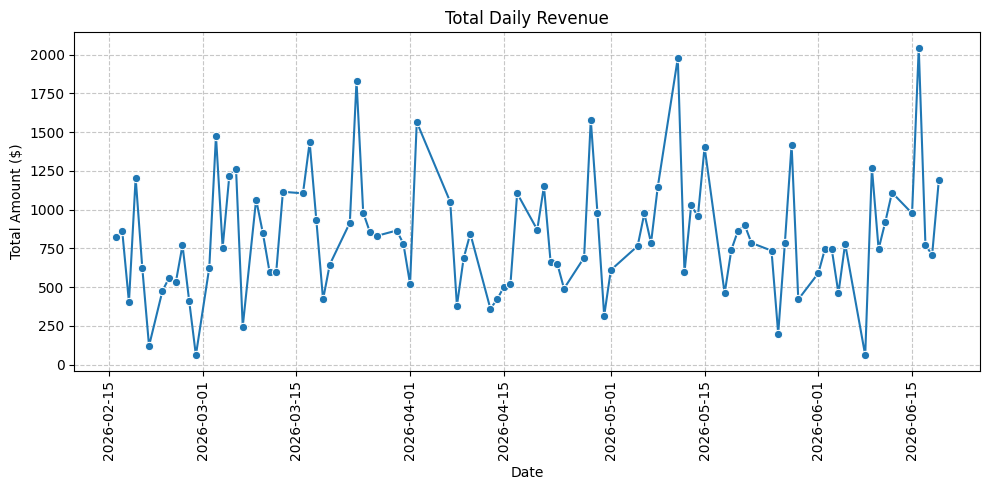

In [20]:
# Flujo de ingresos por día

plt.figure(figsize=(10, 5))
sns.lineplot(data=ingresos_dia, x='Fecha', y='Cantidad', marker='o')
plt.xticks(rotation=90)
plt.title('Total Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Total Amount ($)')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# Obtener el día de la semana
ingresos_dia['Dia_Semana'] = ingresos_dia['Fecha'].dt.day_name()

promedio_por_dia = ingresos_dia.groupby('Dia_Semana')['Cantidad'].mean().reset_index()

print(promedio_por_dia)

  Dia_Semana     Cantidad
0     Friday   868.500000
1     Monday   786.812500
2   Saturday   141.666667
3   Thursday   830.485556
4    Tuesday  1019.611111
5  Wednesday   730.388889


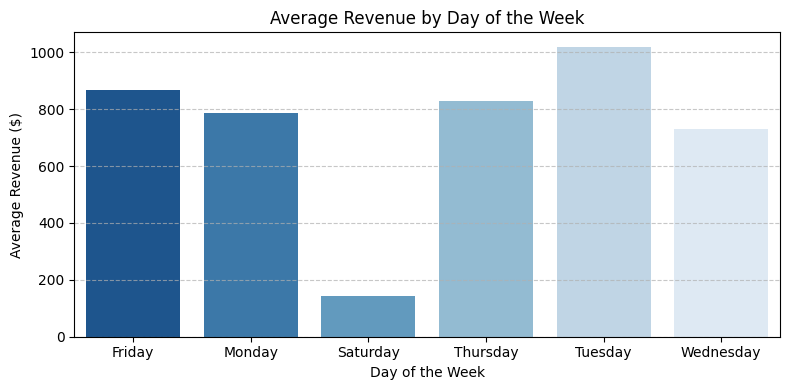

In [22]:
plt.figure(figsize=(8, 4))

# Usamos un gráfico de barras
sns.barplot(data=promedio_por_dia, x='Dia_Semana', y='Cantidad', palette='Blues_r')

plt.title('Average Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show();

In [23]:
# Creemos la columna mes
Ingresos['Mes'] = Ingresos['Fecha'].dt.to_period('M')

ingresos_mensuales = Ingresos.groupby('Mes')['Cantidad'].sum().reset_index()
ingresos_mensuales['Mes_Texto'] = ingresos_mensuales['Mes'].astype(str)

# Ordenamos cronológicamente por si acaso
ingresos_mensuales = ingresos_mensuales.sort_values('Mes_Texto')

# Mostramos la tabla en la consola para ver los números exactos
print(ingresos_mensuales[['Mes_Texto', 'Cantidad']])

  Mes_Texto  Cantidad
0   2026-02   6832.50
1   2026-03  21397.00
2   2026-04  15330.00
3   2026-05  17550.56
4   2026-06  13117.18


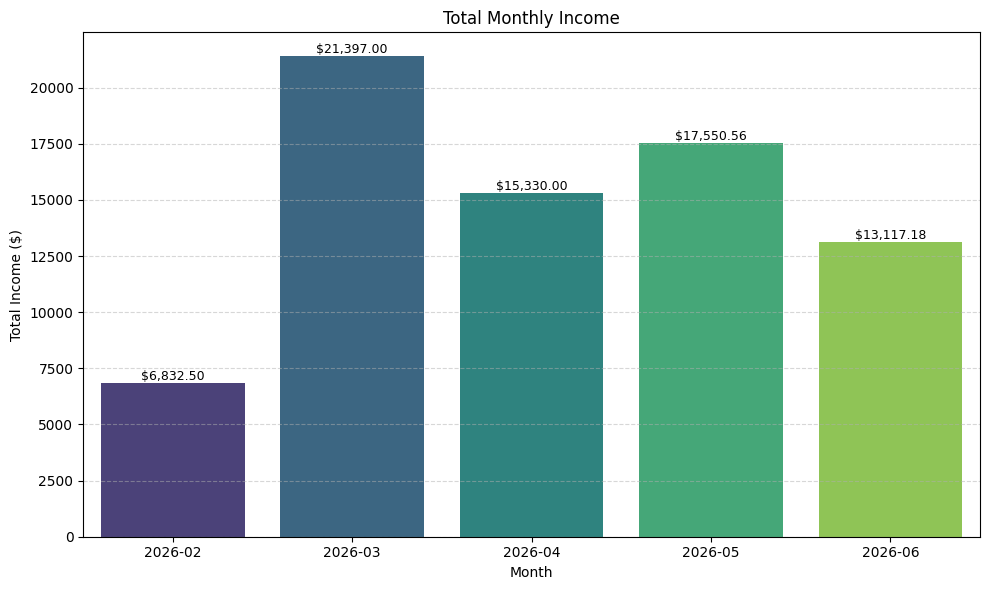

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ingresos_mensuales, x='Mes_Texto', y='Cantidad', palette='viridis')

for index, row in ingresos_mensuales.iterrows():
    plt.text(index, row['Cantidad'], f"${row['Cantidad']:,.2f}", 
             color='black', ha="center", va="bottom", fontsize=9)

plt.title('Total Monthly Income')
plt.xlabel('Month')
plt.ylabel('Total Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

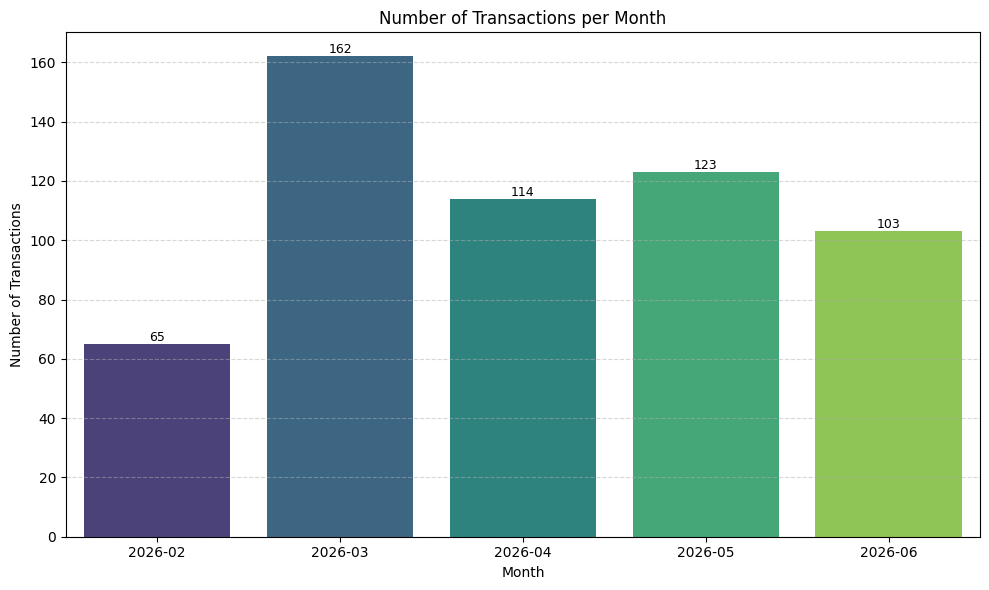

In [25]:
# Evaluemos número de transacciones por mes (no es equivalente a número de clintes)

num_transacciones = Ingresos.groupby('Mes')['Cantidad'].count().reset_index()
num_transacciones = num_transacciones.rename(columns={'Cantidad': 'Total_Transacciones'})

num_transacciones['Mes_Texto'] = num_transacciones['Mes'].astype(str)
num_transacciones = num_transacciones.sort_values('Mes_Texto')

plt.figure(figsize=(10, 6))
sns.barplot(data=num_transacciones, x='Mes_Texto', y='Total_Transacciones', palette='viridis')

for index, row in num_transacciones.iterrows():
    plt.text(index, row['Total_Transacciones'], int(row['Total_Transacciones']), 
             color='black', ha="center", va="bottom", fontsize=9)

plt.title('Number of Transactions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Análisis de costos
- Fijos: renta y salarios
- Variables: ordenes y demás

In [26]:
costos = flow[flow['Categoria'] != 'Transaccion']

In [27]:
costos.value_counts('Categoria')

Categoria
Orders    133
Wages      18
Name: count, dtype: int64

In [28]:
ordenes = flow[flow['Categoria'] == 'Orders']

ordenes_dia = ordenes.groupby('Fecha')['Cantidad'].sum().reset_index()
ordenes_dia = ordenes_dia.sort_values('Fecha')

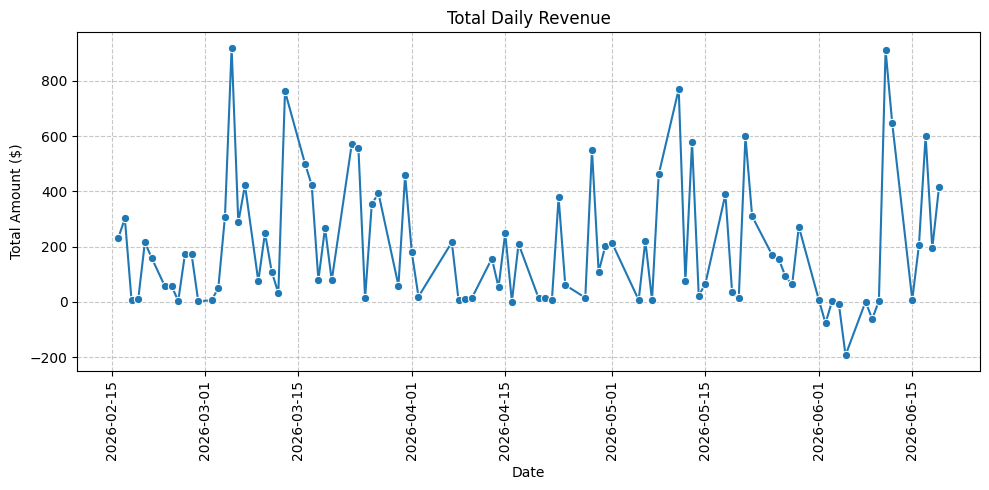

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=ordenes_dia, x='Fecha', y='Cantidad', marker='o')
plt.xticks(rotation=90)
plt.title('Total Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Total Amount ($)')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
# Creemos la columna mes
ordenes['Mes'] = ordenes['Fecha'].dt.to_period('M')

ordenes_mensuales = ordenes.groupby('Mes')['Cantidad'].sum().reset_index()
ordenes_mensuales['Mes_Texto'] = ordenes_mensuales['Mes'].astype(str)

# Ordenamos cronológicamente por si acaso
ordenes_mensuales = ordenes_mensuales.sort_values('Mes_Texto')

# Mostramos la tabla en la consola para ver los números exactos
print(ordenes_mensuales[['Mes_Texto', 'Cantidad']])

  Mes_Texto  Cantidad
0   2026-02   1386.50
1   2026-03   6979.00
2   2026-04   2467.00
3   2026-05   4519.87
4   2026-06   2656.63


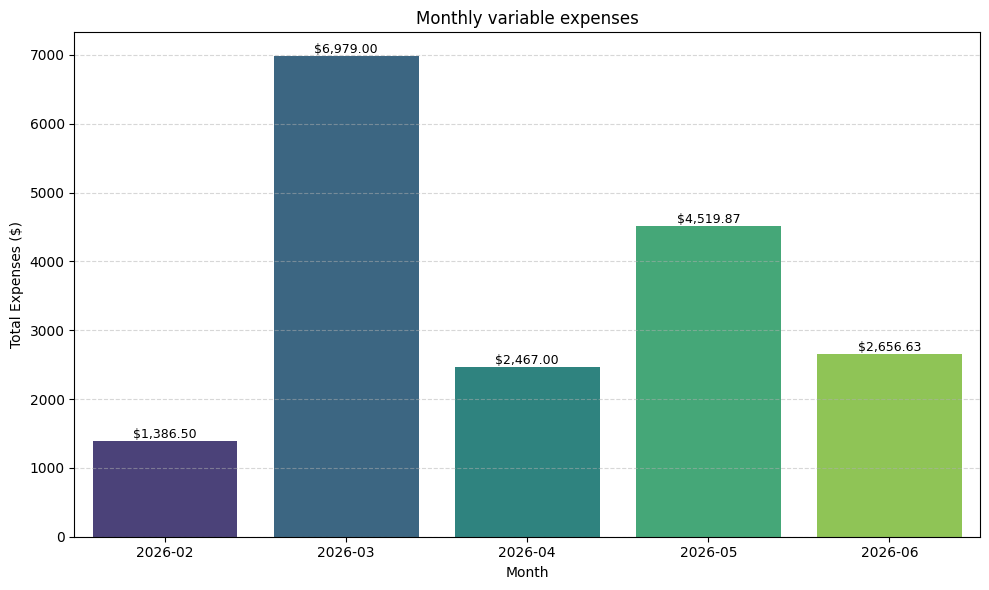

In [31]:
# Evaluemos número de costes variables por mes (no es equivalente a número de clintes)

plt.figure(figsize=(10, 6))
sns.barplot(ordenes_mensuales, x='Mes_Texto', y='Cantidad', palette='viridis')

for index, row in ordenes_mensuales.iterrows():
    plt.text(index, row['Cantidad'], f"${row['Cantidad']:,.2f}", 
             color='black', ha="center", va="bottom", fontsize=9)

plt.title('Monthly variable expenses')
plt.xlabel('Month')
plt.ylabel('Total Expenses ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
flow.Categoria.value_counts()

Categoria
Transaccion    567
Orders         133
Wages           18
Name: count, dtype: int64

## Profits

In [33]:
flow['Categoria'] = flow['Categoria'].astype(str).str.strip().str.lower()

condiciones = [
    flow['Categoria'] == 'transaccion',
    flow['Categoria'].isin(['orders', 'wages'])
]
elecciones = ['Ingreso', 'Costo']

flow['Tipo'] = np.select(condiciones, elecciones, default='Otros')

# Monto Neto: Ingresos suman (+), Costos restan (-)

flow['Monto_Neto'] = flow.apply(
    lambda row: row['Cantidad'] if row['Tipo'] == 'Ingreso' else (-row['Cantidad'] if row['Tipo'] == 'Costo' else 0), 
    axis=1
)

# Creamos la columna de Mes en formato texto para agrupar (ej. '2026-02')
flow['Mes_Texto'] = flow['Fecha'].dt.to_period('M').astype(str)


# sumemos monto neto
ganancias_mensuales = flow.groupby('Mes_Texto')['Monto_Neto'].sum().reset_index()
ganancias_mensuales = ganancias_mensuales.rename(columns={'Monto_Neto': 'Ganancia'})
ganancias_mensuales = ganancias_mensuales.sort_values('Mes_Texto')

print("--- Resumen de Ganancias Mensuales ---")
print(ganancias_mensuales)

--- Resumen de Ganancias Mensuales ---
  Mes_Texto  Ganancia
0   2026-02   1846.00
1   2026-03   7218.00
2   2026-04   6263.00
3   2026-05   4172.69
4   2026-06   5120.55


In [34]:
ganancias_mensuales['Rent'] = 1800
ganancias_mensuales['profits'] = ganancias_mensuales['Ganancia'] - ganancias_mensuales['Rent']
ganancias_mensuales

,Mes_Texto,Ganancia,Rent,profits
0,2026-02,1846.00,1800,46.00
1,2026-03,7218.00,1800,5418.00
2,2026-04,6263.00,1800,4463.00
3,2026-05,4172.69,1800,2372.69
4,2026-06,5120.55,1800,3320.55


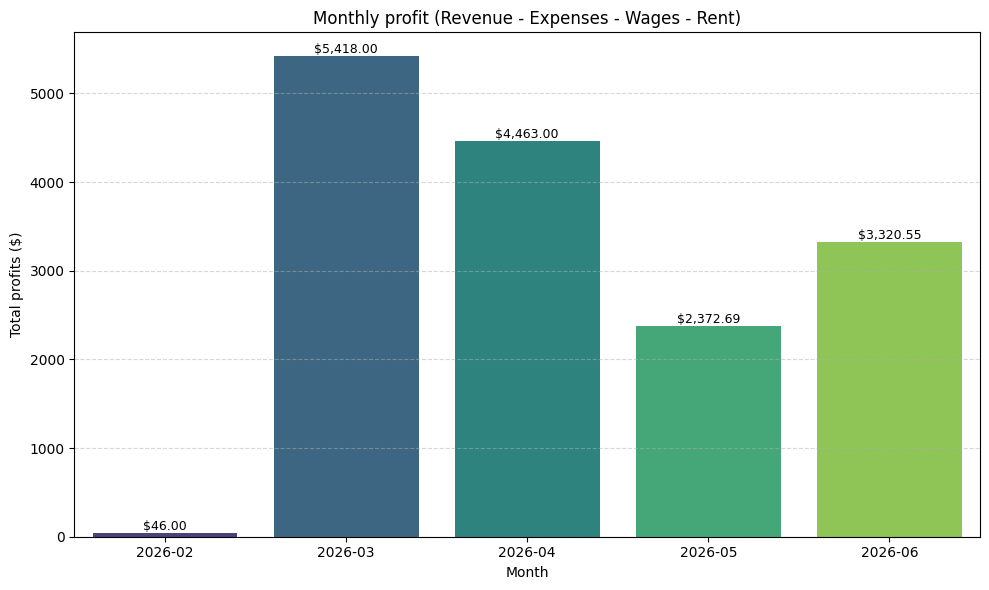

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(ganancias_mensuales, x='Mes_Texto', y='profits', palette='viridis')

for index, row in ganancias_mensuales.iterrows():
    plt.text(index, row['profits'], f"${row['profits']:,.2f}", 
             color='black', ha="center", va="bottom", fontsize=9)

plt.title('Monthly profit (Revenue - Expenses - Wages - Rent)')
plt.xlabel('Month')
plt.ylabel('Total profits ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()